# Generic EMD Forecaster
This notebook demonstrates a baseline forecasting pipeline using Standard EMD decomposition and a modular forecasting model (VIP Compliant).

**Prerequisites:** Ensure `EMD-signal` is installed (`pip install EMD-signal`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import os
import pickle
from abc import ABC, abstractmethod
from PyEMD import EMD as PyEMD_EMD

# Ensure plots display inline
%matplotlib inline

In [2]:
# --- Configuration ---
data_path = "../data/wheat-futures/wheat_futures_daily.csv"
output_dir = "Decomposed_Data"  # To save intermediate CSVs (optional)
LOOKBACK = 30
N_SPLITS = 5
BURN_IN = 60

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
def load_daily_wheat_prices():
    """Load daily wheat futures close prices and return (dates, prices)."""
    # Use path relative to current working directory (Notebook root)
    if not os.path.exists(data_path):
        print(f"Data not found at {data_path}")
        return None, None

    print(f"Loading data from {data_path}...")
    df = pd.read_csv(data_path)
    
    # Identify Date Column
    if 'date' in df.columns:
        date_col = 'date'
    elif 'Date' in df.columns:
        date_col = 'Date'
    else:
        print("Date column not found.")
        return None, None
        
    df[date_col] = pd.to_datetime(df[date_col], utc=True).dt.tz_localize(None)
    df.sort_values(date_col, inplace=True)
    
    return df[date_col].values, df['Close'].values

In [4]:
# ===========================================================================
# Base Abstract Class (VIP Standard)
# ===========================================================================
class BaseForecastModel(ABC):
    """
    Simple base class for forecasting models.
    Your model should inherit from this and implement all the methods below.
    """

    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        pass

    @abstractmethod
    def predict(self, X):
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        pass

    @abstractmethod
    def save(self, filepath: str):
        pass

    @abstractmethod
    def load(self, filepath: str):
        pass

In [5]:
# --- Helper: Create Features ---
def create_lagged_features(data, lookback):
    """Create X (lags) and y (target) for autoregression."""
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i: i + lookback])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

# ===========================================================================
# Generic Decomposition Forecaster Implementation
# ===========================================================================
class GenericDecompositionModel(BaseForecastModel):
    """
    Forecasts a set of decomposed IMFs using an independent model for each component.
    Compliant with BaseForecastModel.
    """
    def __init__(self, task_type='regression', model_type='Linear', lookback=30, **kwargs):
        super().__init__(task_type, **kwargs)
        self.model_type = model_type
        self.lookback = lookback
        self.models = [] # List of fitted models per IMF
        self.n_imfs = 0

    def _get_backend_model(self):
        """Factory to return a model instance."""
        name = self.model_type.lower()
        if name == 'linear':
            return make_pipeline(StandardScaler(), LinearRegression())
        elif name == 'ridge':
            return make_pipeline(StandardScaler(), Ridge(alpha=1.0))
        elif name == 'lasso':
            return make_pipeline(StandardScaler(), Lasso(alpha=0.01))
        elif name == 'tcn':
            # TODO: Import TCN model here
            raise NotImplementedError("TCN not connected yet.")
        else:
            raise ValueError(f"Unknown model: {self.model_type}")

    def fit(self, X_train, y_train=None):
        """
        Train on Decomposed IMFs (X_train).
        X_train shape: (N_samples, n_imfs)
        """
        prices_imf = X_train
        self.n_imfs = prices_imf.shape[1]
        self.models = []

        # Train a separate model for each IMF
        for i in range(self.n_imfs):
            series = prices_imf[:, i]
            # Create features internally
            X_feat, y_target = create_lagged_features(series, self.lookback)
            
            model = self._get_backend_model()
            model.fit(X_feat, y_target)
            self.models.append(model)
            
        return self

    def predict(self, X):
        """
        Make predictions for Total Price (Sum of forecasted IMFs).
        X shape: (N_samples, n_imfs)
        Returns: (N_samples - lookback,)
        """
        if not self.models:
            raise ValueError("Model not trained yet.")
        
        total_pred = None
        
        for i, model in enumerate(self.models):
            series = X[:, i]
            X_feat, _ = create_lagged_features(series, self.lookback)
            
            imf_pred = model.predict(X_feat)
            
            if total_pred is None:
                total_pred = np.zeros_like(imf_pred)
                
            total_pred += imf_pred
            
        return total_pred

    def evaluate(self, X_test, y_test):
        """Compute evaluation metrics (MSE, RMSE, MAE, R2)."""
        preds = self.predict(X_test)
        y_true_aligned = y_test[self.lookback:]
        min_len = min(len(y_true_aligned), len(preds))
        
        y_true = y_true_aligned[:min_len]
        y_pred = preds[:min_len]
        
        # Calculate metrics
        mse = mean_squared_error(y_true, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        
        return {
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            'r2': r2
        }

    def save(self, filepath: str):
        with open(filepath, 'wb') as f:
            pickle.dump({'models': self.models, 'type': self.model_type}, f)

    def load(self, filepath: str):
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
            self.models = data['models']
            self.model_type = data['type']

Loading data from ../data/wheat-futures/wheat_futures_daily.csv...
Loaded 6400 samples.

Running EMD Decomposition...
Decomposition shape: (6400, 10)

Forecasting with Linear Regression...
Fold 1:
  MSE: 88.9016
  RMSE: 9.4288
  MAE: 5.9355
  R2: 0.9983
Fold 2:
  MSE: 70.6165
  RMSE: 8.4034
  MAE: 6.5196
  R2: 0.9956
Fold 3:
  MSE: 18.1581
  RMSE: 4.2612
  MAE: 3.4166
  R2: 0.9977
Fold 4:
  MSE: 24.3391
  RMSE: 4.9335
  MAE: 3.8919
  R2: 0.9966
Fold 5:
  MSE: 73.7616
  RMSE: 8.5885
  MAE: 5.9526
  R2: 0.9973

Average Metrics:
  MSE: 55.1554
  RMSE: 7.1231
  MAE: 5.1432
  R2: 0.9971

Average R²: 0.9971


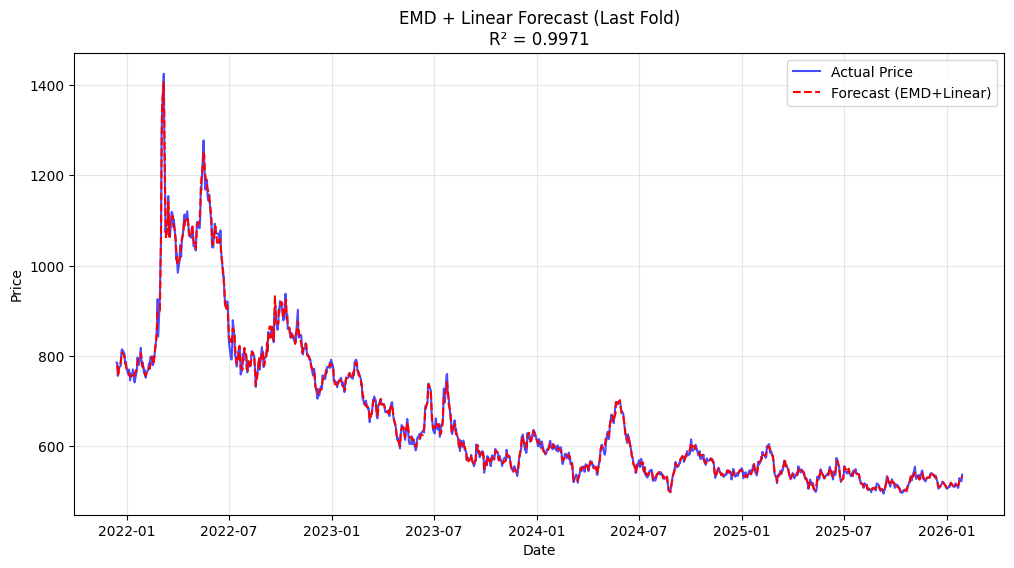

In [6]:
# --- Main Logic: 1. Decompose (EMD), 2. Forecast (Linear) ---

# 1. Load Data
dates, prices = load_daily_wheat_prices()

if prices is not None:
    print(f"Loaded {len(prices)} samples.")

    # 2. Decompose using Standard EMD (Generic Baseline)
    print("\nRunning EMD Decomposition...")
    emd = PyEMD_EMD()
    # EMD returns (n_imfs, n_samples). Transpose to (n_samples, n_imfs)
    imfs = emd.emd(prices).T
    print(f"Decomposition shape: {imfs.shape}")
    
    # 3. Forecast using Generic Forecaster (Linear Regression)
    # Total Price = Sum of IMFs (Reconstruction Check)
    price_recon = np.sum(imfs, axis=1)
    
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_metrics_list = []
    
    indices = np.arange(len(imfs))
    
    last_fold_preds = None
    last_fold_dates = None
    last_fold_true = None

    print("\nForecasting with Linear Regression...")
    for fold, (train_idx, test_idx) in enumerate(tscv.split(indices)):
        if len(train_idx) <= LOOKBACK: continue
            
        imf_train = imfs[train_idx]
        imf_test = imfs[test_idx]
        price_test = price_recon[test_idx]
        
        # Initialize & Fit
        model = GenericDecompositionModel(model_type='linear', lookback=LOOKBACK)
        model.fit(imf_train)
        
        # Predict
        preds = model.predict(imf_test)
        
        
        # Helper for evaluation
        metrics = model.evaluate(imf_test, price_test)
        
        # Store all metrics
        fold_metrics_list.append(metrics)
        
        print(f"Fold {fold+1}:")
        for k, v in metrics.items():
            print(f"  {k.upper()}: {v:.4f}")
        
        # Recalculate aligned Ground Truth for plotting/saving
        y_true = price_test[LOOKBACK:]
        min_len = min(len(y_true), len(preds))
        
        if fold == N_SPLITS - 1:
            last_fold_preds = preds
            # dates[test_idx] gives test dates. Offset by lookback.
            last_fold_dates = dates[test_idx][LOOKBACK:LOOKBACK+min_len]
            last_fold_true = y_true[:min_len]
            
    # Calculate Averages
    print("\nAverage Metrics:")
    avg_metrics = {}
    for k in fold_metrics_list[0].keys():
        avg_metrics[k] = np.mean([m[k] for m in fold_metrics_list])
        print(f"  {k.upper()}: {avg_metrics[k]:.4f}")
            
    print(f"\nAverage R²: {avg_metrics['r2']:.4f}")
    
    # 4. Visualize
    if last_fold_preds is not None:
        plt.figure(figsize=(12, 6))
        plt.plot(last_fold_dates, last_fold_true, label='Actual Price', color='blue', alpha=0.7)
        plt.plot(last_fold_dates, last_fold_preds, label='Forecast (EMD+Linear)', color='red', linestyle='--')
        plt.title(f'EMD + Linear Forecast (Last Fold)\nR² = {avg_metrics["r2"]:.4f}')
        plt.xlabel('Date')
        plt.ylabel('Price')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()